# Encoder Architecture

The Transformer Encoder consists of the following components:

Input Embeddings
        │
        ▼
Positional Encoding
        │
        ▼
Multi-Head Attention
        │
        ▼
Add & LayerNorm
        │
        ▼
Feed Forward Network
        │
        ▼
Add & LayerNorm
        │
        ▼
Encoder Output

The same Encoder Layer is stacked multiple times to build the complete Transformer Encoder.

## Importing Required Libraries

Before implementing positional encoding, we first import the required libraries.

- `torch` is used for tensor operations.
- `torch.nn` provides PyTorch modules that we'll later inherit from.
- `math` is required because the positional encoding formula uses logarithms and exponential functions.

These imports will be used throughout the notebook.

In [1]:
import torch
import torch.nn as nn
import math 

## Defining Hyperparameters

Next, we define two important hyperparameters.

### d_model

This represents the embedding dimension.

If `d_model = 8`, every token embedding will contain 8 numerical values.

In real Transformer models this value is much larger (e.g., 768 or 4096), but we'll use a smaller value so that every tensor is easy to inspect.

### max_len

This represents the maximum sequence length for which positional encodings will be generated.

Here, `max_len = 10` means we'll create positional encodings for positions 0 to 9.

num_heads : Number of Attention Heads

d_ff : Hidden Dimension of Feed Forward Network

In [2]:
d_model=8
max_len=10
num_heads=2
d_ff=32

## Creating the Positional Encoding Matrix

We now create an empty matrix that will eventually store the positional encoding for every position.

The shape of this matrix is:

(max_len, d_model)

For our example,

(10, 8)

This means:

- 10 rows → one row for every possible position.
- 8 columns → one value for every embedding dimension.

Initially, every element is zero because we haven't computed the sine and cosine values yet.

In [3]:
pe=torch.zeros(max_len,d_model)
print(pe)
print(pe.shape)

tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])
torch.Size([10, 8])


## Creating Position Indices

To compute positional encodings, we first need to know the position of every token.

`torch.arange(max_len)` generates a sequence of integers starting from 0 up to `max_len - 1`.

For our example:

[0, 1, 2, 3, ..., 9]

Each number simply represents the position of a token inside a sentence.

In [4]:
position=torch.arange(max_len)
print(position)
print(position.shape)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
torch.Size([10])


## Converting Positions into a Column Vector

Currently, the position tensor has shape:

(10,)

However, later we'll multiply this tensor with another tensor containing different frequency values.

For broadcasting to work correctly, we convert it into a column vector using `unsqueeze(1)`.

Before:

(10,)

After:

(10, 1)

Notice that only the shape changes. The numerical values remain exactly the same.

In [5]:
position=position.unsqueeze(1)
print(position)
print(position.shape)

tensor([[0],
        [1],
        [2],
        [3],
        [4],
        [5],
        [6],
        [7],
        [8],
        [9]])
torch.Size([10, 1])


## Computing the Frequency Term (`div_term`)

The original Transformer paper uses sine and cosine waves with different frequencies for different embedding dimensions.

Instead of manually calculating these frequencies for every dimension, we create a tensor called `div_term`.

Each value inside `div_term` represents a different frequency that will later be used while computing the sine and cosine values.

Notice that we only generate values for the **even dimensions** (`0, 2, 4, ...`).

The odd dimensions will use the same frequencies when computing cosine values.

In [6]:
div_term=torch.exp(
    torch.arange(0,d_model,2)*
    (-math.log(10000.0)/d_model)
)
print(div_term)
print(div_term.shape)

tensor([1.0000e+00, 1.0000e-01, 1.0000e-02, 1.0000e-03])
torch.Size([4])


## Computing the Sine Values

The original paper applies the sine function to all **even embedding dimensions**.

In [7]:
pe[:,0::2]=torch.sin(position*div_term)
print(pe)

tensor([[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.8415,  0.0000,  0.0998,  0.0000,  0.0100,  0.0000,  0.0010,  0.0000],
        [ 0.9093,  0.0000,  0.1987,  0.0000,  0.0200,  0.0000,  0.0020,  0.0000],
        [ 0.1411,  0.0000,  0.2955,  0.0000,  0.0300,  0.0000,  0.0030,  0.0000],
        [-0.7568,  0.0000,  0.3894,  0.0000,  0.0400,  0.0000,  0.0040,  0.0000],
        [-0.9589,  0.0000,  0.4794,  0.0000,  0.0500,  0.0000,  0.0050,  0.0000],
        [-0.2794,  0.0000,  0.5646,  0.0000,  0.0600,  0.0000,  0.0060,  0.0000],
        [ 0.6570,  0.0000,  0.6442,  0.0000,  0.0699,  0.0000,  0.0070,  0.0000],
        [ 0.9894,  0.0000,  0.7174,  0.0000,  0.0799,  0.0000,  0.0080,  0.0000],
        [ 0.4121,  0.0000,  0.7833,  0.0000,  0.0899,  0.0000,  0.0090,  0.0000]])


## Computing the Cosine Values

Just like the sine function was applied to the even embedding dimensions, the cosine function is applied to the odd embedding dimensions.

In [8]:
pe[:, 1::2] = torch.cos(position * div_term)
print(pe)

tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  9.9833e-02,  9.9500e-01,  9.9998e-03,
          9.9995e-01,  1.0000e-03,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  1.9867e-01,  9.8007e-01,  1.9999e-02,
          9.9980e-01,  2.0000e-03,  1.0000e+00],
        [ 1.4112e-01, -9.8999e-01,  2.9552e-01,  9.5534e-01,  2.9995e-02,
          9.9955e-01,  3.0000e-03,  1.0000e+00],
        [-7.5680e-01, -6.5364e-01,  3.8942e-01,  9.2106e-01,  3.9989e-02,
          9.9920e-01,  4.0000e-03,  9.9999e-01],
        [-9.5892e-01,  2.8366e-01,  4.7943e-01,  8.7758e-01,  4.9979e-02,
          9.9875e-01,  5.0000e-03,  9.9999e-01],
        [-2.7942e-01,  9.6017e-01,  5.6464e-01,  8.2534e-01,  5.9964e-02,
          9.9820e-01,  6.0000e-03,  9.9998e-01],
        [ 6.5699e-01,  7.5390e-01,  6.4422e-01,  7.6484e-01,  6.9943e-02,
          9.9755e-01,  6.9999e-03,  9.9998e-01],
        [ 9.8936

## Final Positional Encoding Matrix

The positional encoding matrix now has shape:

(max_len, d_model)

Every row represents one position.

Every column represents one embedding dimension.

This matrix will be added to the word embeddings before they are passed into the Transformer.

In [9]:
print(pe.shape)

torch.Size([10, 8])


## Visualizing the Positional Encoding Matrix

Instead of looking at numbers, let's visualize the positional encoding matrix as a heatmap.

Brighter and darker colors represent different values.

Notice how different embedding dimensions follow different sinusoidal patterns.

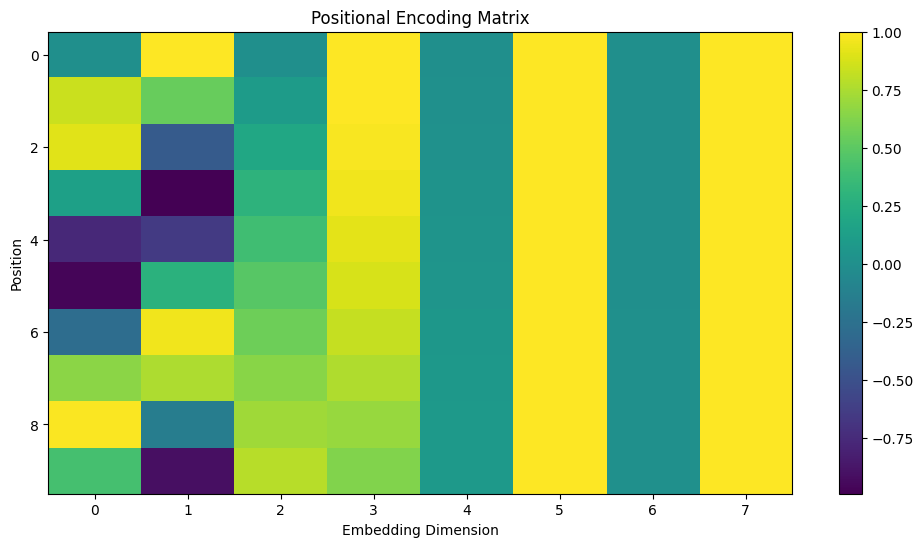

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.imshow(pe, cmap="viridis", aspect="auto")

plt.colorbar()

plt.xlabel("Embedding Dimension")
plt.ylabel("Position")

plt.title("Positional Encoding Matrix")

plt.show()

## Adding Positional Encoding to Embeddings

Suppose our embedding layer produces a tensor of shape:

(batch_size, sequence_length, d_model)

We simply add the positional encoding matrix to the embeddings.

The shape remains exactly the same.

In [11]:
embeddings = torch.randn(2, max_len, d_model)

output = embeddings + pe

print("Embedding Shape :", embeddings.shape)
print("Positional Encoding Shape :", pe.shape)
print("Output Shape :", output.shape)

Embedding Shape : torch.Size([2, 10, 8])
Positional Encoding Shape : torch.Size([10, 8])
Output Shape : torch.Size([2, 10, 8])


# Multi-Head Attention

We implemented Multi-Head Attention in the previous notebook.

Here, we'll reuse the same implementation because the Encoder is built using this module.

The Multi-Head Attention layer allows the model to focus on different relationships between tokens simultaneously.

In [12]:
class MultiHeadAttention(nn.Module):

    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.fc_out = nn.Linear(d_model, d_model)

    def forward(self, query, key, value):

        batch_size = query.shape[0]

        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        Q = Q.view(batch_size, -1, self.num_heads, self.head_dim).transpose(1,2)
        K = K.view(batch_size, -1, self.num_heads, self.head_dim).transpose(1,2)
        V = V.view(batch_size, -1, self.num_heads, self.head_dim).transpose(1,2)

        scores = torch.matmul(Q, K.transpose(-2,-1)) / math.sqrt(self.head_dim)

        attention = torch.softmax(scores, dim=-1)

        out = torch.matmul(attention, V)

        out = out.transpose(1,2).contiguous().view(
            batch_size,
            -1,
            self.d_model
        )

        out = self.fc_out(out)

        return out

# Testing Multi-Head Attention

Before using Multi-Head Attention inside the Encoder, let's verify that it produces the expected output shape.

In [13]:
mha = MultiHeadAttention(d_model, num_heads)

x = torch.randn(2, max_len, d_model)

output = mha(x, x, x)

print(output.shape)

torch.Size([2, 10, 8])


# Add & Layer Normalization

After Multi-Head Attention, the Transformer adds the original input back to the attention output.

This is called a **Residual Connection**.

The result is then normalized using **Layer Normalization**.

Residual Connections help preserve the original information and improve gradient flow during training.

Layer Normalization stabilizes training by keeping activations well-scaled.

In [14]:
class AddNorm(nn.Module):
    def __init__(self,d_model):
        super().__init__()
        self.layer_norm=nn.LayerNorm(d_model)
    def forward(self,x,sublayer_output):
        return self.layer_norm(x+sublayer_output)

# Testing Add & LayerNorm

We'll verify that the output shape remains unchanged.

Input Shape:

(batch_size, sequence_length, d_model)

Output Shape:

(batch_size, sequence_length, d_model)

In [15]:
add_norm = AddNorm(d_model)

x = torch.randn(2, max_len, d_model)
attention_output = torch.randn(2, max_len, d_model)

output = add_norm(x, attention_output)

print(output.shape)

torch.Size([2, 10, 8])


# Feed Forward Network

Every token is processed independently using a small neural network.

The Feed Forward Network consists of:

Linear
↓

ReLU

↓

Linear

Unlike Multi-Head Attention, tokens do not interact with each other here.

Each token is transformed independently.

In [16]:
class FeedForward(nn.Module):

    def __init__(self, d_model, d_ff):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):

        return self.network(x)

# Testing Feed Forward Network

The Feed Forward Network expands the embedding dimension from

d_model → d_ff

and then projects it back to

d_ff → d_model

Therefore, the output shape remains the same as the input.

In [17]:
ffn = FeedForward(d_model, d_ff)

x = torch.randn(2, max_len, d_model)

output = ffn(x)

print(output.shape)

torch.Size([2, 10, 8])


# Building the Encoder Layer

Now we'll combine everything we've built so far.

One Encoder Layer consists of:

Input
↓

Multi-Head Attention

↓

Add & LayerNorm

↓

Feed Forward Network

↓

Add & LayerNorm

↓

Output

This is the basic building block of the Transformer Encoder.

In [18]:
class EncoderLayer(nn.Module):

    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()

        self.attention = MultiHeadAttention(d_model, num_heads)

        self.norm1 = AddNorm(d_model)

        self.ffn = FeedForward(d_model, d_ff)

        self.norm2 = AddNorm(d_model)

    def forward(self, x):

        attention_output = self.attention(x, x, x)

        x = self.norm1(x, attention_output)

        ffn_output = self.ffn(x)

        x = self.norm2(x, ffn_output)

        return x

# Testing a Single Encoder Layer

Before stacking multiple layers, let's verify that a single Encoder Layer works correctly.

In [19]:
encoder_layer = EncoderLayer(
    d_model,
    num_heads,
    d_ff
)

x = torch.randn(2, max_len, d_model)

output = encoder_layer(x)

print(output.shape)

torch.Size([2, 10, 8])


# Stacking Multiple Encoder Layers

The original Transformer stacks multiple identical Encoder Layers.

Instead of manually writing several layers, we use `nn.ModuleList`.

Each layer receives the output of the previous layer.

In [20]:
class TransformerEncoder(nn.Module):

    def __init__(self,
                 d_model,
                 num_heads,
                 d_ff,
                 num_layers):

        super().__init__()

        self.layers = nn.ModuleList([
            EncoderLayer(
                d_model,
                num_heads,
                d_ff
            )
            for _ in range(num_layers)
        ])

    def forward(self, x):

        for layer in self.layers:
            x = layer(x)

        return x

# Testing the Complete Transformer Encoder

We'll stack three Encoder Layers and pass a random tensor through them.

If everything has been implemented correctly, the output shape should remain unchanged.

In [21]:
encoder = TransformerEncoder(
    d_model=d_model,
    num_heads=num_heads,
    d_ff=d_ff,
    num_layers=3
)

x = torch.randn(2, max_len, d_model)

output = encoder(x)

print("Input Shape :", x.shape)
print("Output Shape:", output.shape)

Input Shape : torch.Size([2, 10, 8])
Output Shape: torch.Size([2, 10, 8])
